# Notebook 19 — Frozen Strategy Tear Sheet, Research Ledger & Deployment Readiness

## SuperbCommand — Multi-Asset CTA Strategy

**Purpose:** consolidate the completed research programme into a single reproducible research record after the 2026 holdout was opened.

This notebook does **not** optimise, select, tune, or alter the strategy. It is a post-research reporting and governance notebook.

### Frozen architecture entering deployment review
- Long/cash SuperbCommand architecture.
- Equity Early-Reversal entry: **2-step 50/50**.
- Non-equity Early-Reversal entry: **immediate**.
- Pullback state: **hold 1.00x; no additional exposure**.
- Profit-taking: unchanged from the accepted upstream architecture.
- Portfolio construction: **hierarchical inverse volatility**.
- Generic reciprocal/inverse shorting: rejected.
- No leverage overlay or crisis-alpha short overlay is introduced here.
- 2026 has been opened and is therefore permanently treated as **seen data**.

### Holdout interpretation
The 2026 holdout contained 36 weekly observations through the evaluation date. The frozen portfolio returned approximately 9.0%, with annualised return 13.26%, annualised volatility 4.37%, Sharpe 2.87 and maximum drawdown approximately -1.99%.

The equity Early-Reversal 2-step modification generated **no differential 2026 return**, because the complete 108-row equity holdout panel (SPY, EFA, EEM; 36 weeks each) contained **zero Early-Reversal starts, active weeks, or ends**. The modification is therefore *not exercised / not yet tested in the final holdout*, rather than passed, failed, or tied.

## Research-governance rule
Any strategy change motivated by 2026 information belongs to a **new research version** and must not be described as validated by the original 2026 holdout.

In [1]:
# ============================================================
# 1. PROJECT CONFIGURATION
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_19"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EQUITY_TICKERS = ["SPY", "EFA", "EEM"]
UNIVERSE = ["SPY", "EFA", "EEM", "SHY", "IEF", "TLT", "TIP", "GLD", "DBC", "UUP", "BTC-USD"]

ASSET_CLASS_MAP = {
    "SPY": "equities", "EFA": "equities", "EEM": "equities",
    "SHY": "rates", "IEF": "rates", "TLT": "rates", "TIP": "rates",
    "GLD": "commodities", "DBC": "commodities",
    "UUP": "fx", "BTC-USD": "crypto",
}

print("Notebook 19 output directory:")
print(OUTPUT_DIR)

Notebook 19 output directory:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/outputs/notebook_19


## 2. Research decision ledger

This ledger separates **accepted**, **rejected**, **deferred**, and **not-exercised-in-holdout** findings. It is deliberately qualitative: Notebook 19 must not manufacture precision by reconstructing results that should instead be read from the original research notebooks.

In [2]:
# ============================================================
# 2. RESEARCH DECISION LEDGER
# ============================================================

ledger = pd.DataFrame([
    ["Portfolio construction", "Hierarchical inverse volatility", "ACCEPTED",
     "Robust/simple portfolio construction; avoids asset-count representation bias."],
    ["Generic shorting", "Reciprocal/inverse short architecture", "REJECTED",
     "Did not justify replacing the long/cash primary architecture."],
    ["Asset-class specialist substitution", "Broad specialist mapping", "REJECTED",
     "Did not robustly beat the strong Dual Trend benchmark."],
    ["Equity SuperbCommand substitution", "Equity SC incremental value", "SUPPORTIVE",
     "Cleanest incremental SuperbCommand evidence in signal-substitution decomposition."],
    ["Equity Early-Reversal pacing", "2-step 50/50", "ACCEPTED",
     "Parsimonious implementation refinement; small but stable pre-holdout evidence."],
    ["Dynamic ER pacing selection", "Walk-forward schedule selector", "REJECTED",
     "Dynamic selection underperformed simply fixing the parsimonious 2-step rule."],
    ["Non-equity ER pacing", "Immediate entry", "ACCEPTED",
     "No sufficiently robust case for staged deployment."],
    ["Pullback accumulation", "Hold at 1.00x", "ACCEPTED",
     "Adding exposure degraded the portfolio response curve and stress behaviour."],
    ["Pullback leverage", "10% to 50% additions", "REJECTED",
     "Higher additions generally reduced Sharpe and worsened stress drawdowns."],
    ["Crisis-alpha short overlay", "Separate defensive short sleeve", "DEFERRED",
     "Potential future research topic; not part of frozen architecture."],
    ["2026 equity ER holdout test", "2-step vs immediate", "NOT EXERCISED",
     "Zero SPY/EFA/EEM Early-Reversal starts, active weeks and ends in 108 observations."],
], columns=["research_component", "decision", "status", "rationale"])

display(ledger)
ledger.to_csv(OUTPUT_DIR / "research_decision_ledger.csv", index=False)

,research_component,decision,status,rationale
0,Portfolio construction,Hierarchical inverse volatility,ACCEPTED,Robust/simple portfolio construction; avoids a...
1,Generic shorting,Reciprocal/inverse short architecture,REJECTED,Did not justify replacing the long/cash primar...
2,Asset-class specialist substitution,Broad specialist mapping,REJECTED,Did not robustly beat the strong Dual Trend be...
3,Equity SuperbCommand substitution,Equity SC incremental value,SUPPORTIVE,Cleanest incremental SuperbCommand evidence in...
4,Equity Early-Reversal pacing,2-step 50/50,ACCEPTED,Parsimonious implementation refinement; small ...
5,Dynamic ER pacing selection,Walk-forward schedule selector,REJECTED,Dynamic selection underperformed simply fixing...
6,Non-equity ER pacing,Immediate entry,ACCEPTED,No sufficiently robust case for staged deploym...
7,Pullback accumulation,Hold at 1.00x,ACCEPTED,Adding exposure degraded the portfolio respons...
8,Pullback leverage,10% to 50% additions,REJECTED,Higher additions generally reduced Sharpe and ...
9,Crisis-alpha short overlay,Separate defensive short sleeve,DEFERRED,Potential future research topic; not part of f...


## 3. Frozen architecture manifest

The manifest below is the machine-readable definition of the strategy version that existed when the 2026 holdout was evaluated. It is a governance record, not an attempt to recreate every upstream signal parameter.

In [3]:
# ============================================================
# 3. FROZEN ARCHITECTURE MANIFEST
# ============================================================

frozen_manifest = {
    "project": "SuperbCommand - Multi-Asset CTA Strategy",
    "research_stage": "post_2026_holdout_lockbox",
    "architecture": {
        "direction": "long_cash",
        "equity_early_reversal_entry": "2_step_50_50",
        "other_early_reversal_entry": "immediate",
        "pullback_exposure": 1.00,
        "pullback_addition": 0.00,
        "profit_taking": "unchanged_from_accepted_upstream_architecture",
        "portfolio_construction": "hierarchical_inverse_volatility",
        "generic_shorting": False,
        "crisis_alpha_short_overlay": False,
    },
    "universe": UNIVERSE,
    "asset_class_map": ASSET_CLASS_MAP,
    "holdout": {
        "calendar_year": 2026,
        "status": "OPENED_AND_PERMANENTLY_SEEN",
        "observed_weeks": 36,
        "portfolio_total_return": 0.09,
        "annualised_return": 0.132558,
        "annualised_volatility": 0.043685,
        "sharpe": 2.874162,
        "sortino": 3.223936,
        "max_drawdown": -0.019864,
        "equity_er_modification_effect": 0.0,
        "equity_er_holdout_classification": "NOT_EXERCISED",
        "equity_er_observations_checked": 108,
        "equity_er_start_events": 0,
        "equity_er_active_weeks": 0,
        "equity_er_end_events": 0,
    },
    "governance": {
        "may_reoptimise_using_2026_and_still_call_2026_untouched_holdout": False,
        "future_2026_informed_changes_require_new_research_version": True,
    },
}

manifest_path = OUTPUT_DIR / "frozen_strategy_manifest.json"
manifest_path.write_text(json.dumps(frozen_manifest, indent=2))

print(json.dumps(frozen_manifest, indent=2))
print("\nSaved:", manifest_path)

{
  "project": "SuperbCommand - Multi-Asset CTA Strategy",
  "research_stage": "post_2026_holdout_lockbox",
  "architecture": {
    "direction": "long_cash",
    "equity_early_reversal_entry": "2_step_50_50",
    "other_early_reversal_entry": "immediate",
    "pullback_exposure": 1.0,
    "pullback_addition": 0.0,
    "profit_taking": "unchanged_from_accepted_upstream_architecture",
    "portfolio_construction": "hierarchical_inverse_volatility",
    "generic_shorting": false,
    "crisis_alpha_short_overlay": false
  },
  "universe": [
    "SPY",
    "EFA",
    "EEM",
    "SHY",
    "IEF",
    "TLT",
    "TIP",
    "GLD",
    "DBC",
    "UUP",
    "BTC-USD"
  ],
  "asset_class_map": {
    "SPY": "equities",
    "EFA": "equities",
    "EEM": "equities",
    "SHY": "rates",
    "IEF": "rates",
    "TLT": "rates",
    "TIP": "rates",
    "GLD": "commodities",
    "DBC": "commodities",
    "UUP": "fx",
    "BTC-USD": "crypto"
  },
  "holdout": {
    "calendar_year": 2026,
    "status": "O

## 4. Holdout tear sheet

The holdout metrics are recorded exactly as established in Notebook 18. The purpose here is presentation and archival consistency, not further inference from a short 36-week sample.

In [4]:
# ============================================================
# 4. 2026 HOLDOUT TEAR SHEET
# ============================================================

holdout_metrics = pd.DataFrame({
    "metric": [
        "Weeks", "Total return", "Annualised return", "Annualised volatility",
        "Sharpe", "Sortino", "Maximum drawdown", "Calmar",
        "Best week", "Worst week", "Positive week rate"
    ],
    "value": [
        36, 0.09, 0.132558, 0.043685,
        2.874162, 3.223936, -0.019864, 6.67314,
        0.012457, -0.015368, 0.694444
    ]
})

display(holdout_metrics)
holdout_metrics.to_csv(OUTPUT_DIR / "2026_holdout_metrics.csv", index=False)

,metric,value
0,Weeks,36.000000
1,Total return,0.090000
2,Annualised return,0.132558
3,Annualised volatility,0.043685
4,Sharpe,2.874162
5,Sortino,3.223936
6,Maximum drawdown,-0.019864
7,Calmar,6.673140
8,Best week,0.012457
9,Worst week,-0.015368


In [5]:
# ============================================================
# 5. 2026 HOLDOUT CONTRIBUTION SNAPSHOT
# ============================================================

ticker_attribution = pd.DataFrame([
    ["BTC-USD", "crypto",       0.007219],
    ["DBC",     "commodities",  0.040702],
    ["EEM",     "equities",     0.013485],
    ["EFA",     "equities",     0.008701],
    ["GLD",     "commodities", -0.001307],
    ["IEF",     "rates",       -0.000259],
    ["SHY",     "rates",        0.000261],
    ["SPY",     "equities",     0.010126],
    ["TIP",     "rates",        0.000191],
    ["TLT",     "rates",       -0.000519],
    ["UUP",     "fx",           0.008324],
], columns=["ticker", "asset_class", "return_contribution"])

asset_attribution = (
    ticker_attribution.groupby("asset_class", as_index=False)["return_contribution"]
    .sum()
    .sort_values("return_contribution", ascending=False)
)

display(asset_attribution)
display(ticker_attribution.sort_values("return_contribution", ascending=False))

ticker_attribution.to_csv(OUTPUT_DIR / "2026_ticker_attribution.csv", index=False)
asset_attribution.to_csv(OUTPUT_DIR / "2026_asset_class_attribution.csv", index=False)

,asset_class,return_contribution
0,commodities,0.039395
2,equities,0.032312
3,fx,0.008324
1,crypto,0.007219
4,rates,-0.000326


,ticker,asset_class,return_contribution
1,DBC,commodities,0.040702
2,EEM,equities,0.013485
7,SPY,equities,0.010126
3,EFA,equities,0.008701
10,UUP,fx,0.008324
0,BTC-USD,crypto,0.007219
6,SHY,rates,0.000261
8,TIP,rates,0.000191
5,IEF,rates,-0.000259
9,TLT,rates,-0.000519


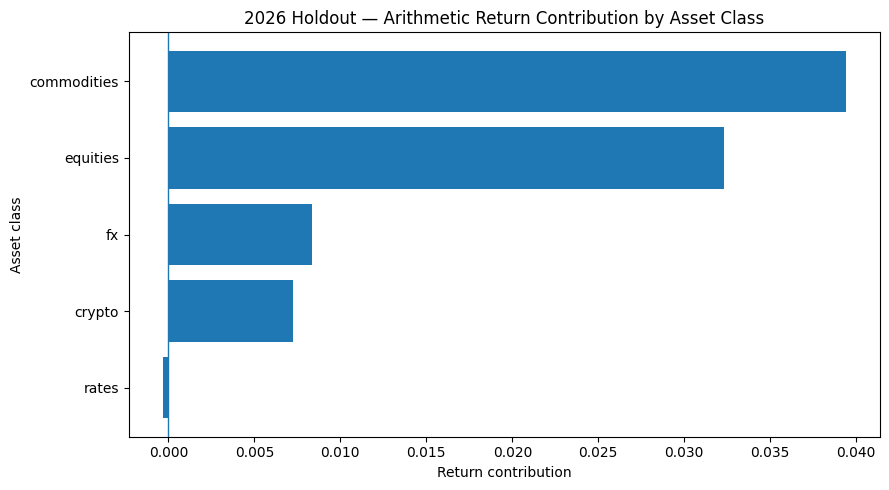

Saved: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/outputs/notebook_19/2026_asset_class_attribution.png


In [6]:
# ============================================================
# 6. HOLDOUT ATTRIBUTION CHART
# ============================================================

plot_df = asset_attribution.sort_values("return_contribution")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["asset_class"], plot_df["return_contribution"])
ax.axvline(0, linewidth=1)
ax.set_title("2026 Holdout — Arithmetic Return Contribution by Asset Class")
ax.set_xlabel("Return contribution")
ax.set_ylabel("Asset class")
fig.tight_layout()

chart_path = OUTPUT_DIR / "2026_asset_class_attribution.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", chart_path)

## 7. Deployment-readiness checklist

This is intentionally stricter than a performance scorecard. A research strategy can have attractive historical metrics and still be unready for capital because execution, data integrity, operational controls, or live monitoring are incomplete.

In [7]:
# ============================================================
# 7. DEPLOYMENT-READINESS CHECKLIST
# ============================================================

readiness = pd.DataFrame([
    ["Frozen signal rules documented", True, "Upstream signal engine + frozen architecture manifest."],
    ["Portfolio construction frozen", True, "Hierarchical inverse volatility."],
    ["Generic shorting decision frozen", True, "Rejected."],
    ["Equity ER pacing decision frozen", True, "2-step 50/50."],
    ["Pullback sizing decision frozen", True, "Hold 1.00x."],
    ["Final holdout opened only after freeze", True, "2026 opened after architecture freeze."],
    ["Holdout status permanently recorded as seen", True, "Research-governance rule enforced."],
    ["ER holdout zero-effect explained", True, "No equity ER activation in 108 observations."],
    ["Transaction-cost/slippage assumptions reviewed for live use", False, "Must be explicitly verified before capital deployment."],
    ["Corporate-action / symbol / data-quality controls reviewed", False, "Operational review required."],
    ["Live signal reconciliation against TradingView/source logic", False, "Run shadow/live-paper reconciliation."],
    ["Order-generation and execution controls tested", False, "Required for deployment implementation."],
    ["Position/risk limit controls implemented", False, "Required for live capital."],
    ["Failure/restart/state-persistence handling tested", False, "Required for operational resilience."],
    ["Live monitoring and alerting implemented", False, "Required before unattended operation."],
], columns=["check", "complete", "note"])

display(readiness)

completed = int(readiness["complete"].sum())
total = len(readiness)

print(f"Research/deployment checklist: {completed}/{total} complete")
print("This is NOT a strategy-performance score.")

readiness.to_csv(OUTPUT_DIR / "deployment_readiness_checklist.csv", index=False)

,check,complete,note
0,Frozen signal rules documented,True,Upstream signal engine + frozen architecture m...
1,Portfolio construction frozen,True,Hierarchical inverse volatility.
2,Generic shorting decision frozen,True,Rejected.
3,Equity ER pacing decision frozen,True,2-step 50/50.
4,Pullback sizing decision frozen,True,Hold 1.00x.
5,Final holdout opened only after freeze,True,2026 opened after architecture freeze.
6,Holdout status permanently recorded as seen,True,Research-governance rule enforced.
7,ER holdout zero-effect explained,True,No equity ER activation in 108 observations.
8,Transaction-cost/slippage assumptions reviewed...,False,Must be explicitly verified before capital dep...
9,Corporate-action / symbol / data-quality contr...,False,Operational review required.


Research/deployment checklist: 8/15 complete
This is NOT a strategy-performance score.


## 8. Future research register

The original 2026 holdout can no longer validate changes inspired by what has now been observed. Future work should therefore be explicitly separated into either:

1. **Frozen-model monitoring** — no model changes; accumulate genuinely new observations.
2. **New-version research** — strategy changes are allowed, but require a new validation protocol and a new future holdout.

This distinction prevents the project from quietly converting a final holdout into another optimisation sample.

In [8]:
# ============================================================
# 8. FUTURE RESEARCH REGISTER
# ============================================================

future_research = pd.DataFrame([
    ["Frozen live/paper monitoring", "MONITORING", "High",
     "Accumulate genuinely new observations without changing rules."],
    ["Equity ER first live activation audit", "MONITORING", "High",
     "When the first new equity ER event occurs, verify 50/50 exposure mechanics; do not retune."],
    ["Transaction costs and execution realism", "IMPLEMENTATION", "High",
     "Validate turnover, spreads, slippage and rebalance timing before capital deployment."],
    ["Signal reconciliation / shadow trading", "IMPLEMENTATION", "High",
     "Compare production signals with research signals observation by observation."],
    ["Crisis-alpha short sleeve", "NEW_VERSION_RESEARCH", "Medium",
     "Separate overlay research; cannot reuse 2026 as an untouched final holdout."],
    ["Broader instrument universe / futures implementation", "NEW_VERSION_RESEARCH", "Medium",
     "Test whether proxy-ETF conclusions survive a more institutional implementation."],
    ["Profit-taking architecture refinement", "NEW_VERSION_RESEARCH", "Low",
     "Only if economically motivated; must be treated as a new model version."],
], columns=["item", "track", "priority", "governance_note"])

display(future_research)
future_research.to_csv(OUTPUT_DIR / "future_research_register.csv", index=False)

,item,track,priority,governance_note
0,Frozen live/paper monitoring,MONITORING,High,Accumulate genuinely new observations without ...
1,Equity ER first live activation audit,MONITORING,High,"When the first new equity ER event occurs, ver..."
2,Transaction costs and execution realism,IMPLEMENTATION,High,"Validate turnover, spreads, slippage and rebal..."
3,Signal reconciliation / shadow trading,IMPLEMENTATION,High,Compare production signals with research signa...
4,Crisis-alpha short sleeve,NEW_VERSION_RESEARCH,Medium,Separate overlay research; cannot reuse 2026 a...
5,Broader instrument universe / futures implemen...,NEW_VERSION_RESEARCH,Medium,Test whether proxy-ETF conclusions survive a m...
6,Profit-taking architecture refinement,NEW_VERSION_RESEARCH,Low,Only if economically motivated; must be treate...


## 9. Research lockbox statement

**Notebook 19 closes the original research programme as a frozen research version.**

The 2026 data are now seen. The correct use of subsequent 2026 observations is frozen-model monitoring, not retrospective re-optimisation. If a new architecture is researched using knowledge obtained after opening the holdout, it must receive a new version identity and a new future validation period.

The equity 2-step Early-Reversal rule remains part of the frozen architecture because its adoption preceded the holdout. Its lack of 2026 differential performance is not evidence for or against the rule: the state simply did not activate in the observed holdout.

In [9]:
# ============================================================
# 9. WRITE NOTEBOOK-19 RESEARCH LOCKBOX RECORD
# ============================================================

lockbox = {
    "notebook": 19,
    "title": "Frozen Strategy Tear Sheet, Research Ledger & Deployment Readiness",
    "research_version_status": "FROZEN",
    "2026_status": "SEEN",
    "strategy_change_permitted_in_this_notebook": False,
    "holdout_reoptimization_permitted": False,
    "equity_er_2026_status": "NOT_EXERCISED",
    "next_valid_tracks": [
        "frozen_model_monitoring",
        "deployment_engineering",
        "new_version_research_with_new_future_holdout"
    ]
}

lockbox_path = OUTPUT_DIR / "research_lockbox_record.json"
lockbox_path.write_text(json.dumps(lockbox, indent=2))

print(json.dumps(lockbox, indent=2))
print("\nSaved:", lockbox_path)

{
  "notebook": 19,
  "title": "Frozen Strategy Tear Sheet, Research Ledger & Deployment Readiness",
  "research_version_status": "FROZEN",
  "2026_status": "SEEN",
  "strategy_change_permitted_in_this_notebook": false,
  "holdout_reoptimization_permitted": false,
  "equity_er_2026_status": "NOT_EXERCISED",
  "next_valid_tracks": [
    "frozen_model_monitoring",
    "deployment_engineering",
    "new_version_research_with_new_future_holdout"
  ]
}

Saved: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/outputs/notebook_19/research_lockbox_record.json


## End of Notebook 19

### Final interpretation

The original SuperbCommand multi-asset CTA research version is now **frozen**.

Notebook 19 deliberately does not search for another backtest improvement after seeing the 2026 holdout. The next high-value work is operational: transaction-cost realism, signal reconciliation, paper/shadow execution, state persistence, risk controls, and live monitoring. New alpha or architecture research should be branched into a separately governed model version.